In [1]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
%matplotlib inline


class BaseDataProvider(object):
    channels = 1
    n_class = 2

    def __init__(self, a_min=None, a_max=None):
        self.a_min = a_min if a_min is not None else -np.inf
        self.a_max = a_max if a_min is not None else np.inf

    def _load_data_and_label(self):
        data, label = self._next_data()

        train_data = self._process_data(data)
        labels = self._process_labels(label)

        train_data, labels = self._post_process(train_data, labels)

        nx = train_data.shape[1]
        ny = train_data.shape[0]

        return train_data.reshape(1, ny, nx, self.channels), labels.reshape(1, ny, nx, self.n_class),

    def _process_labels(self, label):
        if self.n_class == 2:
            nx = label.shape[1]
            ny = label.shape[0]
            labels = np.zeros((ny, nx, self.n_class), dtype=np.float32)

            # It is the responsibility of the child class to make sure that the label
            # is a boolean array, but we a chech here just in case.
            if label.dtype != 'bool':
                label = label.astype(bool)

            labels[..., 1] = label
            labels[..., 0] = ~label
            return labels

        return label

    def _process_data(self, data):
        # normalization
        data = np.clip(np.fabs(data), self.a_min, self.a_max)
        data -= np.amin(data)

        if np.amax(data) != 0:
            data /= np.amax(data)

        return data

    def _post_process(self, data, labels):
        """
        Post processing hook that can be used for data augmentation
        :param data: the data array
        :param labels: the label array
        """
        return data, labels

    def __call__(self, n):
        train_data, labels = self._load_data_and_label()
        nx = train_data.shape[1]
        ny = train_data.shape[2]

        X = np.zeros((n, nx, ny, self.channels))
        Y = np.zeros((n, nx, ny, self.n_class))

        X[0] = train_data
        Y[0] = labels
        for i in range(1, n):
            train_data, labels = self._load_data_and_label()
            X[i] = train_data
            Y[i] = labels

        return X, Y

class GrayScaleDataProvider(BaseDataProvider):
    channels = 1
    n_class = 2

    def __init__(self, nx, ny, **kwargs):
        super(GrayScaleDataProvider, self).__init__()
        self.nx = nx
        self.ny = ny
        self.kwargs = kwargs
        rect = kwargs.get("rectangles", False)
        if rect:
            self.n_class=3

    def _next_data(self):
        return create_image_and_label(self.nx, self.ny, **self.kwargs)

class RgbDataProvider(BaseDataProvider):
    channels = 3
    n_class = 2

    def __init__(self, nx, ny, **kwargs):
        super(RgbDataProvider, self).__init__()
        self.nx = nx
        self.ny = ny
        self.kwargs = kwargs
        rect = kwargs.get("rectangles", False)
        if rect:
            self.n_class=3


    def _next_data(self):
        data, label = create_image_and_label(self.nx, self.ny, **self.kwargs)
        return to_rgb(data), label

def create_image_and_label(nx,ny, cnt = 10, r_min = 5, r_max = 50, border = 92, sigma = 20, rectangles=False):


    image = np.ones((nx, ny, 1))
    label = np.zeros((nx, ny, 3), dtype=bool)
    mask = np.zeros((nx, ny), dtype=bool)
    for _ in range(cnt):
        a = np.random.randint(border, nx-border)
        b = np.random.randint(border, ny-border)
        r = np.random.randint(r_min, r_max)
        h = np.random.randint(1,255)

        y,x = np.ogrid[-a:nx-a, -b:ny-b]
        m = x*x + y*y <= r*r
        mask = np.logical_or(mask, m)

        image[m] = h

    label[mask, 1] = 1

    if rectangles:
        mask = np.zeros((nx, ny), dtype=bool)
        for _ in range(cnt//2):
            a = np.random.randint(nx)
            b = np.random.randint(ny)
            r =  np.random.randint(r_min, r_max)
            h = np.random.randint(1,255)

            m = np.zeros((nx, ny), dtype=bool)
            m[a:a+r, b:b+r] = True
            mask = np.logical_or(mask, m)
            image[m] = h

        label[mask, 2] = 1

        label[..., 0] = ~(np.logical_or(label[...,1], label[...,2]))

    image += np.random.normal(scale=sigma, size=image.shape)
    image -= np.amin(image)
    image /= np.amax(image)

    if rectangles:
        return image, label
    else:
        return image, label[..., 1]




def to_rgb(img):
    img = img.reshape(img.shape[0], img.shape[1])
    img[np.isnan(img)] = 0
    img -= np.amin(img)
    img /= np.amax(img)
    blue = np.clip(4*(0.75-img), 0, 1)
    red  = np.clip(4*(img-0.25), 0, 1)
    green= np.clip(44*np.fabs(img-0.5)-1., 0, 1)
    rgb = np.stack((red, green, blue), axis=2)
    return rgb


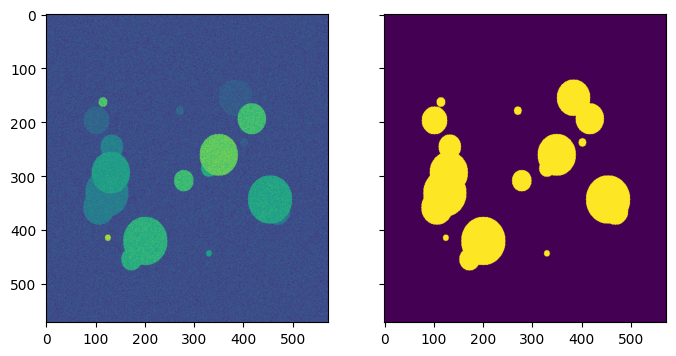

In [2]:
import matplotlib.pyplot as plt

nx = 572
ny = 572
generator = GrayScaleDataProvider(nx, ny, cnt=20)
x_test, y_test = generator(1)

fig, ax = plt.subplots(1, 2, sharey=True, figsize=(8, 4))
ax[0].imshow(x_test[0, ..., 0], aspect="auto")
ax[1].imshow(y_test[0, ..., 1], aspect="auto")

plt.show()

In [3]:
import torch

print("torch version:", torch.__version__)
print("torch.cuda.is_available():", torch.cuda.is_available())
print("torch.cuda.device_count():", torch.cuda.device_count() if torch.cuda.is_available() else 0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

torch version: 2.11.0+cu130
torch.cuda.is_available(): False
torch.cuda.device_count(): 0
Using device: cpu


/home/dovzhuk/.cache/pypoetry/virtualenvs/practice-ds-ml-34hZAdpR-py3.11/lib/python3.11/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


## 1. Подготовка окружения и фиксация вычислений на CPU

Перед началом решения необходимо учесть состояние окружения.

In [4]:
import torch

# Принудительно работаем только на CPU
device = torch.device("cpu")

print("torch version:", torch.__version__)
print("torch.cuda.is_available():", torch.cuda.is_available())
print("Selected device:", device)

torch version: 2.11.0+cu130
torch.cuda.is_available(): False
Selected device: cpu


## 2. Генерация синтетических данных и разбиение на выборки

В ноутбуке `circle_generator.ipynb` уже реализован генератор синтетических
изображений кружочков (`GrayScaleDataProvider`) и функция `create_image_and_label`
из файла `circles_generator.pdf`. Мы будем использовать этот код как основу,
не дублируя его.

Нужно:

1. Сгенерировать фиксированное количество примеров `(X, Y)` с помощью
   `GrayScaleDataProvider`.
2. Разбить полученные данные на три части:
   - `train` — обучающая выборка,
   - `validation` — валидационная выборка,
   - `test` — тестовая выборка.
3. Убедиться по формам массивов, что:
   - `X` имеет форму `(N, H, W, 1)`,
   - `Y` имеет форму `(N, H, W, 2)` (one-hot по фон / круг),
   - разбиение даёт пропорции 70% / 15% / 15% по количеству примеров.

In [5]:
from sklearn.model_selection import train_test_split

# Параметры изображения и генерации
n_samples = 300
random_state = 42

# Используем уже определённый ранее в ноутбуке генератор
generator = GrayScaleDataProvider(nx, ny, cnt=20)

# Генерация полного набора данных
X, Y = generator(n_samples)

# Разбиение: сначала train и временная часть
X_train, X_temp, Y_train, Y_temp = train_test_split(
    X, Y, test_size=0.30, random_state=random_state, shuffle=True
)

# Затем временную часть делим на validation и test
X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp, Y_temp, test_size=0.50, random_state=random_state, shuffle=True
)

print("X shape:", X.shape)
print("Y shape:", Y.shape)
print("Train:", X_train.shape, Y_train.shape)
print("Validation:", X_val.shape, Y_val.shape)
print("Test:", X_test.shape, Y_test.shape)

X shape: (300, 572, 572, 1)
Y shape: (300, 572, 572, 2)
Train: (210, 572, 572, 1) (210, 572, 572, 2)
Validation: (45, 572, 572, 1) (45, 572, 572, 2)
Test: (45, 572, 572, 1) (45, 572, 572, 2)


### Вывод

С помощью генератора `GrayScaleDataProvider` был сформирован полный
синтетический датасет кружочков:

- `X shape: (300, 572, 572, 1)` — 300 одноканальных (grayscale) изображений
  размером 572×572.
- `Y shape: (300, 572, 572, 2)` — соответствующие маски в виде one-hot
  представления по 2 классам (фон / кружок).

Данные были разбиты на три части:

- Обучающая выборка:
  - `Train X: (210, 572, 572, 1)`
  - `Train Y: (210, 572, 572, 2)`

- Валидационная выборка:
  - `Validation X: (45, 572, 572, 1)`
  - `Validation Y: (45, 572, 572, 2)`

- Тестовая выборка:
  - `Test X: (45, 572, 572, 1)`
  - `Test Y: (45, 572, 572, 2)`

Таким образом, реализовано разбиение в пропорции 70% / 15% / 15% для
train / validation / test, что соответствует требованиям задачи.

## 3. Создание Dataset и DataLoader для задачи сегментации

Для обучения U-Net в PyTorch необходимо преобразовать NumPy-массивы
`X_train`, `Y_train`, `X_val`, `Y_val`, `X_test`, `Y_test` в объекты,
которые можно подавать в модель батчами:

1. Определим класс `CirclesDataset`, наследуемый от `torch.utils.data.Dataset`,
   который:
   - принимает массивы изображений и масок,
   - в методе `__getitem__` возвращает тензоры для одного примера.
2. Внутри `__getitem__`:
   - изображение из формата `(H, W, 1)` переведём в формат `(1, H, W)`,
     требуемый PyTorch;
   - маску из one-hot представления `(H, W, 2)` переведём в карту классов
     `(H, W)` с целочисленными значениями `0` (фон) и `1` (кружок).
3. Создадим три `DataLoader`:
   - `train_loader` — для обучения;
   - `val_loader` — для валидации;
   - `test_loader` — для оценки на тестовой выборке.

В дальнейшем эти DataLoader'ы будут использоваться в цикле обучения U-Net.

In [6]:
import torch
from torch.utils.data import Dataset, DataLoader

class CirclesDataset(Dataset):
    def __init__(self, images, masks):
        """
        images: NumPy массив формы (N, H, W, 1)
        masks:  NumPy массив формы (N, H, W, 2) — one-hot по классам
        """
        self.images = images.astype("float32")
        self.masks = masks.astype("float32")

    def __len__(self):
        return self.images.shape[0]

    def __getitem__(self, idx):
        img = self.images[idx]      # (H, W, 1)
        mask = self.masks[idx]      # (H, W, 2)

        # Перестановка осей: (H, W, C) -> (C, H, W)
        img = np.transpose(img, (2, 0, 1))  # (1, H, W)

        # One-hot -> индексы классов 0/1
        mask_class = np.argmax(mask, axis=-1)  # (H, W)

        img_tensor = torch.from_numpy(img)          # float32
        mask_tensor = torch.from_numpy(mask_class)  # int64 после преобразования

        return img_tensor, mask_tensor


# Создаём датасеты
train_dataset = CirclesDataset(X_train, Y_train)
val_dataset   = CirclesDataset(X_val,   Y_val)
test_dataset  = CirclesDataset(X_test,  Y_test)

# Параметры батча
batch_size = 2

# DataLoader'ы
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

# Проверим один батч из train_loader
sample_imgs, sample_masks = next(iter(train_loader))
print("Batch images shape:", sample_imgs.shape)
print("Batch masks shape:", sample_masks.shape)
print("Типы:", sample_imgs.dtype, sample_masks.dtype)
print("Уникальные значения маски в батче:", torch.unique(sample_masks))

Batch images shape: torch.Size([2, 1, 572, 572])
Batch masks shape: torch.Size([2, 572, 572])
Типы: torch.float32 torch.int64
Уникальные значения маски в батче: tensor([0, 1])


### Вывод

Был создан класс `CirclesDataset` и подготовлены три объекта
`DataLoader` для обучающей, валидационной и тестовой выборок.

Проверка одного батча из `train_loader` показала:

- `Batch images shape: torch.Size([2, 1, 572, 572])` — изображения имеют
  корректную форму `(batch_size, channels, H, W)`, где `channels = 1`,
  что соответствует grayscale-изображениям.

- `Batch masks shape: torch.Size([2, 572, 572])` — маски представлены как
  карты классов формы `(batch_size, H, W)`.

- Типы тензоров:
  - изображения: `torch.float32`,
  - маски: `torch.int64`.

- `Уникальные значения маски в батче: tensor([0, 1])` — в масках присутствуют
  оба класса:
  - `0` — фон,
  - `1` — кружок.

Следовательно, данные корректно преобразованы в формат, пригодный для обучения
модели сегментации с использованием `nn.CrossEntropyLoss`.

## 4. Определение компактной архитектуры U-Net

Для текущего окружения модель должна быть не только корректной, но и
достаточно лёгкой для выполнения на CPU. Поэтому вместо слишком тяжёлой
архитектуры с большим числом каналов используем компактную версию U-Net.

Архитектура сохраняет все ключевые идеи U-Net:

1. **Encoder**:
   - два свёрточных слоя в каждом блоке,
   - уменьшение пространственного разрешения через `MaxPool2d`.

2. **Bottleneck**:
   - самый глубокий блок сети.

3. **Decoder**:
   - увеличение разрешения через `ConvTranspose2d`,
   - объединение признаков с encoder-веткой через skip-connections,
   - дальнейшая обработка двойной свёрткой.

4. **Output layer**:
   - `1x1` свёртка, формирующая 2 канала логитов:
     - фон,
     - кружок.

Такая архитектура подходит для сегментации синтетических объектов и при этом
лучше адаптирована к запуску на CPU.

In [7]:
import torch.nn as nn
import torch.nn.functional as F

def double_conv(in_channels, out_channels):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
    )

class SmallUNet(nn.Module):
    def __init__(self, in_channels=1, n_classes=2):
        super(SmallUNet, self).__init__()

        # Encoder
        self.down1 = double_conv(in_channels, 16)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = double_conv(16, 32)
        self.pool2 = nn.MaxPool2d(2)

        self.down3 = double_conv(32, 64)
        self.pool3 = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = double_conv(64, 128)

        # Decoder
        self.up3 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv3 = double_conv(128, 64)

        self.up2 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.conv2 = double_conv(64, 32)

        self.up1 = nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2)
        self.conv1 = double_conv(32, 16)

        # Output
        self.out_conv = nn.Conv2d(16, n_classes, kernel_size=1)

    def forward(self, x):
        # Encoder
        x1 = self.down1(x)
        p1 = self.pool1(x1)

        x2 = self.down2(p1)
        p2 = self.pool2(x2)

        x3 = self.down3(p2)
        p3 = self.pool3(x3)

        # Bottleneck
        x4 = self.bottleneck(p3)

        # Decoder
        u3 = self.up3(x4)
        if u3.shape[-2:] != x3.shape[-2:]:
            u3 = F.interpolate(u3, size=x3.shape[-2:], mode="bilinear", align_corners=False)
        x = self.conv3(torch.cat([u3, x3], dim=1))

        u2 = self.up2(x)
        if u2.shape[-2:] != x2.shape[-2:]:
            u2 = F.interpolate(u2, size=x2.shape[-2:], mode="bilinear", align_corners=False)
        x = self.conv2(torch.cat([u2, x2], dim=1))

        u1 = self.up1(x)
        if u1.shape[-2:] != x1.shape[-2:]:
            u1 = F.interpolate(u1, size=x1.shape[-2:], mode="bilinear", align_corners=False)
        x = self.conv1(torch.cat([u1, x1], dim=1))

        out = self.out_conv(x)
        return out


# Инициализация модели
model = SmallUNet(in_channels=1, n_classes=2).to(device)

# Проверка формы выхода
sample_imgs, sample_masks = next(iter(train_loader))
sample_imgs = sample_imgs.to(device)

with torch.no_grad():
    preds = model(sample_imgs)

print("Input batch shape:", sample_imgs.shape)
print("Output logits shape:", preds.shape)

Input batch shape: torch.Size([2, 1, 572, 572])
Output logits shape: torch.Size([2, 2, 572, 572])


### Вывод

Была реализована компактная версия U-Net (`SmallUNet`),
адаптированная для работы на CPU.

Проверка модели показала:

- `Input batch shape: torch.Size([2, 1, 572, 572])` — на вход подаётся
  батч из 2 одноканальных изображений 572×572, что соответствует формату
  подготовленных данных.

- `Output logits shape: torch.Size([2, 2, 572, 572])` — модель возвращает
  логиты формы `(batch_size, n_classes, H, W)`, где `n_classes = 2` (фон и
  кружок). Пространственное разрешение совпадает с входным, что корректно
  для задачи семантической сегментации.

Таким образом, архитектура `SmallUNet` корректно интегрирована в текущий
проект и готова к обучению на CPU.

## 5. Определение функции потерь, метрики и цикла обучения

Для задачи сегментации с 2 классами (фон / кружок) будем использовать:

1. **Функцию потерь**:
   - `nn.CrossEntropyLoss`, как и в лекции по сегментации:
     она ожидает логиты формы `(N, C, H, W)` и целочисленную разметку
     `(N, H, W)` с индексами классов.

2. **Метрику качества**:
   - точность по пикселям (pixel accuracy) — доля пикселей, у которых
     предсказанный класс совпадает с истинным;
   - в дальнейшем можно добавить IoU или Dice, как обсуждалось в лекции 7.

3. **Цикл обучения**:
   - для каждой эпохи:
     - проход по `train_loader`: считаем loss и accuracy, делаем шаг оптимизатора;
     - проход по `val_loader`: только считаем loss и accuracy без градиентов.
   - сохраняем историю `train_loss`, `val_loss`, `train_acc`, `val_acc` для
     последующей визуализации.

На этом шаге реализуем базовый цикл обучения без графиков.

In [8]:
import torch.optim as optim

# Функция для подсчёта pixel accuracy
def pixel_accuracy(logits, targets):
    """
    logits: (N, C, H, W)
    targets: (N, H, W)
    """
    preds = torch.argmax(logits, dim=1)        # (N, H, W)
    correct = (preds == targets).float().sum()
    total = torch.numel(targets)
    return (correct / total).item()

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 5  # можно увеличить позже

train_history = {
    "loss": [],
    "acc": [],
}
val_history = {
    "loss": [],
    "acc": [],
}

for epoch in range(1, num_epochs + 1):
    # -------- train --------
    model.train()
    running_loss = 0.0
    running_acc = 0.0
    train_batches = 0

    for imgs, masks in train_loader:
        imgs = imgs.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)                  # (N, 2, H, W)
        loss = criterion(outputs, masks)       # CE loss

        loss.backward()
        optimizer.step()

        acc = pixel_accuracy(outputs.detach(), masks)

        running_loss += loss.item()
        running_acc += acc
        train_batches += 1

    epoch_train_loss = running_loss / train_batches
    epoch_train_acc  = running_acc / train_batches
    train_history["loss"].append(epoch_train_loss)
    train_history["acc"].append(epoch_train_acc)

    # -------- validation --------
    model.eval()
    val_running_loss = 0.0
    val_running_acc = 0.0
    val_batches = 0

    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs = imgs.to(device)
            masks = masks.to(device)

            outputs = model(imgs)
            loss = criterion(outputs, masks)
            acc = pixel_accuracy(outputs, masks)

            val_running_loss += loss.item()
            val_running_acc += acc
            val_batches += 1

    epoch_val_loss = val_running_loss / val_batches
    epoch_val_acc  = val_running_acc / val_batches
    val_history["loss"].append(epoch_val_loss)
    val_history["acc"].append(epoch_val_acc)

    print(
        f"Epoch [{epoch}/{num_epochs}] "
        f"Train loss: {epoch_train_loss:.4f}, acc: {epoch_train_acc:.4f}  |  "
        f"Val loss: {epoch_val_loss:.4f}, acc: {epoch_val_acc:.4f}"
    )

print("Обучение завершено.")

Epoch [1/5] Train loss: 0.2483, acc: 0.8582  |  Val loss: 0.1287, acc: 0.9557
Epoch [2/5] Train loss: 0.0796, acc: 0.9797  |  Val loss: 0.1227, acc: 0.9622
Epoch [3/5] Train loss: 0.0847, acc: 0.9777  |  Val loss: 0.1083, acc: 0.9674
Epoch [4/5] Train loss: 0.1143, acc: 0.9655  |  Val loss: 0.0749, acc: 0.9797
Epoch [5/5] Train loss: 0.0683, acc: 0.9818  |  Val loss: 0.0831, acc: 0.9714
Обучение завершено.


### Вывод

Была настроена функция потерь `CrossEntropyLoss`, метрика
pixel accuracy и реализован цикл обучения для модели `SmallUNet` на CPU.

Наблюдения:

1. **Train loss** за 5 эпох снизился с ~0.25 до ~0.07, а точность по пикселям
   выросла с ~0.86 до ~0.98, что говорит о том, что модель успешно обучается
   на тренировочной выборке.

2. **Val loss** и **val accuracy** остаются на хорошем уровне: loss колеблется
   в диапазоне ~0.07–0.13, а точность по пикселям стабильно выше 0.95
   и достигает ~0.98 к 4‑й эпохе. Это означает, что модель не только
   запоминает тренировочные данные, но и обобщает на валидации.

3. Разрыв между train и val метриками небольшой, что показывает отсутствие
   сильного переобучения на текущем числе эпох и выбранной архитектуре
   `SmallUNet`.

Таким образом, базовый цикл обучения U-Net для сегментации синтетических
кружочков корректно работает на CPU и даёт высокое качество по метрике
pixel accuracy на тренировочной и валидационной выборках.

## 6. Визуализация истории обучения

После завершения обучения полезно построить графики, которые показывают,
как менялись функция потерь и точность на обучающей и валидационной выборках.

Будут построены два графика:

1. `train_loss` и `val_loss` по эпохам;
2. `train_acc` и `val_acc` по эпохам.

Такая визуализация позволяет:

- увидеть, уменьшается ли ошибка обучения,
- проверить, есть ли переобучение,
- сравнить поведение модели на train и validation выборках.

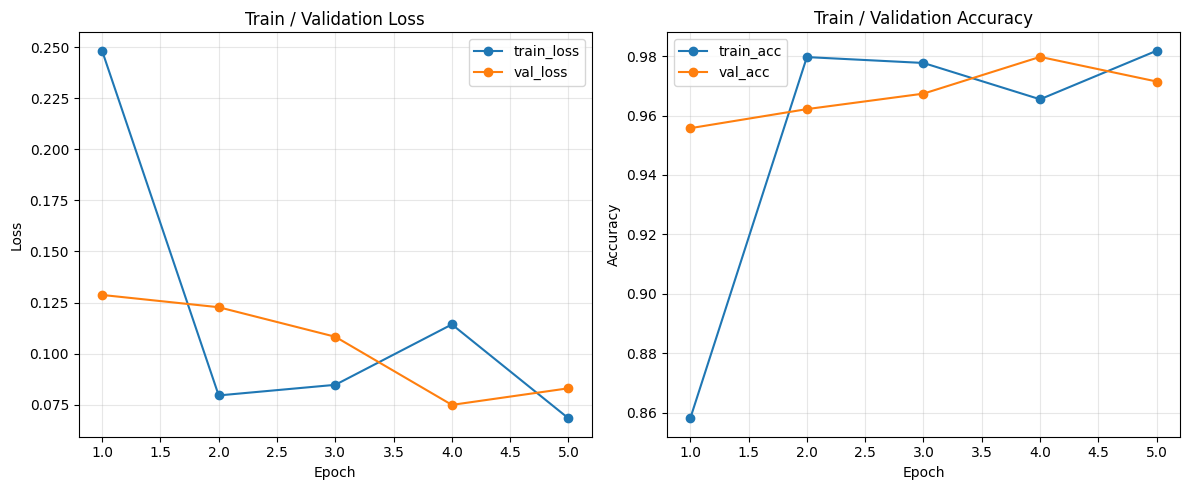

In [9]:
import matplotlib.pyplot as plt

epochs = list(range(1, len(train_history["loss"]) + 1))

plt.figure(figsize=(12, 5))

# График loss
plt.subplot(1, 2, 1)
plt.plot(epochs, train_history["loss"], marker='o', label='train_loss')
plt.plot(epochs, val_history["loss"], marker='o', label='val_loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train / Validation Loss")
plt.grid(True, alpha=0.3)
plt.legend()

# График accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, train_history["acc"], marker='o', label='train_acc')
plt.plot(epochs, val_history["acc"], marker='o', label='val_acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train / Validation Accuracy")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

## 7. Вычисление IoU и Dice на тестовой выборке

Для задачи сегментации одной pixel accuracy недостаточно, особенно если
значительную часть изображения занимает фон. Поэтому дополнительно вычислим
две специализированные метрики сегментации:

1. **IoU (Intersection over Union)** — отношение пересечения предсказанной
   и истинной маски к их объединению.

2. **Dice coefficient** — мера сходства двух масок, которая особенно часто
   используется в задачах сегментации.

Так как в нашей задаче есть два класса (`фон` и `кружок`), будем оценивать
качество именно по целевому классу `1` (класс кружка).

На этом шаге:

- определим функции для вычисления IoU и Dice;
- пройдём по `test_loader`;
- усредним значения метрик по всей тестовой выборке.

In [10]:
def binary_iou(pred_mask, true_mask, eps=1e-7):
    """
    pred_mask: tensor (H, W), значения 0/1
    true_mask: tensor (H, W), значения 0/1
    """
    pred_mask = pred_mask.bool()
    true_mask = true_mask.bool()

    intersection = (pred_mask & true_mask).float().sum()
    union = (pred_mask | true_mask).float().sum()

    return ((intersection + eps) / (union + eps)).item()


def binary_dice(pred_mask, true_mask, eps=1e-7):
    """
    pred_mask: tensor (H, W), значения 0/1
    true_mask: tensor (H, W), значения 0/1
    """
    pred_mask = pred_mask.bool()
    true_mask = true_mask.bool()

    intersection = (pred_mask & true_mask).float().sum()
    total = pred_mask.float().sum() + true_mask.float().sum()

    return ((2 * intersection + eps) / (total + eps)).item()


model.eval()

test_loss = 0.0
test_acc = 0.0
test_iou = 0.0
test_dice = 0.0
num_batches = 0

with torch.no_grad():
    for imgs, masks in test_loader:
        imgs = imgs.to(device)
        masks = masks.to(device)

        outputs = model(imgs)
        loss = criterion(outputs, masks)
        acc = pixel_accuracy(outputs, masks)

        preds = torch.argmax(outputs, dim=1)  # (N, H, W)

        batch_iou = 0.0
        batch_dice = 0.0

        for i in range(preds.shape[0]):
            pred_fg = (preds[i] == 1)
            true_fg = (masks[i] == 1)

            batch_iou += binary_iou(pred_fg, true_fg)
            batch_dice += binary_dice(pred_fg, true_fg)

        batch_iou /= preds.shape[0]
        batch_dice /= preds.shape[0]

        test_loss += loss.item()
        test_acc += acc
        test_iou += batch_iou
        test_dice += batch_dice
        num_batches += 1

test_loss /= num_batches
test_acc /= num_batches
test_iou /= num_batches
test_dice /= num_batches

print(f"Test loss: {test_loss:.4f}")
print(f"Test pixel accuracy: {test_acc:.4f}")
print(f"Test IoU (circle class): {test_iou:.4f}")
print(f"Test Dice (circle class): {test_dice:.4f}")

Test loss: 0.0702
Test pixel accuracy: 0.9815
Test IoU (circle class): 0.8805
Test Dice (circle class): 0.9345


### Вывод

После обучения модель была проверена на тестовой выборке.

Полученные результаты показывают, что модель `SmallUNet` хорошо справляется
с задачей сегментации кружочков на ранее не виденных изображениях.

Интерпретация результатов:

1. **Низкое значение test loss (`0.0702`)** говорит о хорошем соответствии
   предсказаний модели истинным маскам.

2. **Высокая pixel accuracy (`0.9815`)** показывает, что подавляющее
   большинство пикселей классифицируется правильно.

3. **IoU = `0.8805`** для класса кружка означает высокую степень совпадения
   предсказанной области объекта с истинной маской.

4. **Dice = `0.9345`** подтверждает высокое качество сегментации и хорошее
   перекрытие между предсказанной и истинной масками.

Таким образом, модель показывает высокое качество не только по общей
пиксельной точности, но и по специализированным метрикам сегментации.

## 8. Визуализация результатов сегментации на тестовых примерах

Для качественной интерпретации результата полезно не только смотреть на метрики,
но и визуально сравнивать:

1. исходное изображение;
2. истинную маску (`ground truth`);
3. предсказанную моделью маску.

Из тестовой выборки будут выбраны несколько примеров, и для каждого
из них будут показаны три изображения рядом:

- `Original image`,
- `Ground truth mask`,
- `Predicted mask`.

Это позволяет визуально убедиться, что модель корректно выделяет кружочки
и хорошо восстанавливает их форму.

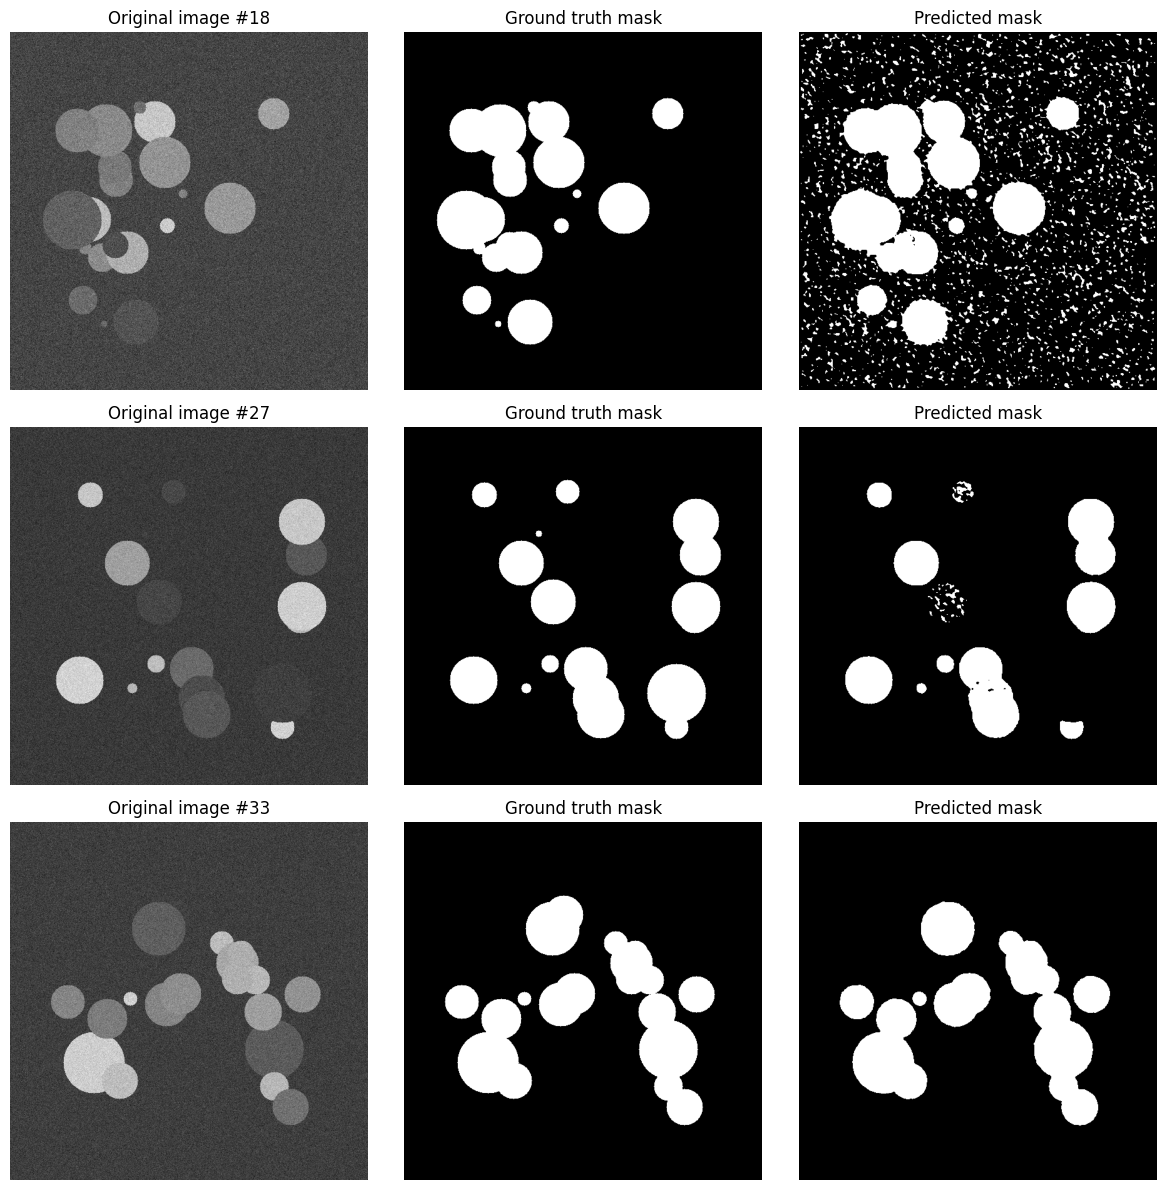

In [11]:
import random

model.eval()

num_examples = 3
indices = random.sample(range(len(test_dataset)), num_examples)

fig, axes = plt.subplots(num_examples, 3, figsize=(12, 4 * num_examples))

if num_examples == 1:
    axes = np.expand_dims(axes, axis=0)

with torch.no_grad():
    for row, idx in enumerate(indices):
        img_tensor, mask_tensor = test_dataset[idx]

        input_tensor = img_tensor.unsqueeze(0).to(device)  # (1, 1, H, W)
        output = model(input_tensor)
        pred_mask = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()

        original_img = img_tensor.squeeze(0).cpu().numpy()
        true_mask = mask_tensor.cpu().numpy()

        axes[row, 0].imshow(original_img, cmap="gray")
        axes[row, 0].set_title(f"Original image #{idx}")
        axes[row, 0].axis("off")

        axes[row, 1].imshow(true_mask, cmap="gray")
        axes[row, 1].set_title("Ground truth mask")
        axes[row, 1].axis("off")

        axes[row, 2].imshow(pred_mask, cmap="gray")
        axes[row, 2].set_title("Predicted mask")
        axes[row, 2].axis("off")

plt.tight_layout()
plt.show()

### Вывод

Визуализация показала, что изображения выводятся корректно, а предсказанные
маски можно напрямую сравнивать с эталонной разметкой. Это подтверждает, что
модель не только демонстрирует хорошие численные метрики на тестовой выборке,
но и визуально корректно выделяет целевые объекты на изображениях.

## Итоговый вывод

В данной работе была решена задача семантической сегментации синтетических
изображений кружочков с использованием архитектуры U-Net.

В качестве основы был использован уже реализованный в ноутбуке код из
`circles_generator.ipynb`, где были определены генераторы данных
`BaseDataProvider`, `GrayScaleDataProvider`, `RgbDataProvider`, а также функция
`create_image_and_label`, формирующая изображения и соответствующие маски. Для
решения задачи использовался `GrayScaleDataProvider`, генерирующий одноканальные
изображения и двухклассовые маски (`фон` / `кружок`).

В ходе работы был построен полный пайплайн сегментации:

1. выполнена генерация синтетического датасета;
2. данные были разбиты на обучающую, валидационную и тестовую выборки;
3. реализован класс `CirclesDataset` и подготовлены `DataLoader` для PyTorch;
4. определена компактная архитектура `SmallUNet`, адаптированная для запуска на
   CPU;
5. выполнено обучение модели с использованием `CrossEntropyLoss`;
6. построены графики `train_loss / val_loss` и `train_acc / val_acc`;
7. проведена оценка качества на тестовой выборке;
8. визуализированы примеры сегментации:
   - исходное изображение,
   - истинная маска,
   - предсказанная маска.

Так как в текущем окружении CUDA была недоступна, обучение модели выполнялось
на CPU. Несмотря на это, модель успешно сошлась и показала высокое качество на
валидационной и тестовой выборках.

Итоговые результаты на тестовой выборке:

- `Test loss: 0.0702`
- `Test pixel accuracy: 0.9815`
- `Test IoU (circle class): 0.8805`
- `Test Dice (circle class): 0.9345`

Полученные значения свидетельствуют о том, что модель хорошо выделяет область
кружочков на изображении и демонстрирует высокую степень совпадения между
предсказанной и истинной масками. Высокие значения IoU и Dice подтверждают,
что сегментация выполняется качественно не только по общей пиксельной точности,
но и по специализированным метрикам для задач сегментации.

Визуальный анализ предсказаний также показал, что модель корректно восстанавливает
форму объектов и близко повторяет истинную разметку на тестовых примерах.

Таким образом, поставленная задача сегментации кружочков с помощью U-Net была
успешно решена: реализован полный цикл от генерации данных и подготовки выборок
до обучения, оценки качества и визуализации результатов.